## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
Regression is used for finding the best correlation between numerical values while classification is used to find the best correlation between categorical values.

2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
A confusion matrix helps us understand the efficiency of our model's performance by comparing its true and false positive and negative values.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
Accuracy is how effective a predictive model is at predicting the true value of a model. It is not entirely sufficient to evaluate a classifier's predictive performance because it can portray a false narrative or lead to overfitting. 

4. What does the root mean squared error quantify about a particular model?
RMSE measures the distance between a models predictive value and its true value

5. What are overfitting and underfitting? 
   Overfitting is when a models accuracy and training is drastically tailored to the specific dataset, but is not applicable/useful in other cases. Underfitting is the opposite, but is still not applicable/useful in other cases.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
Splitting the data into training and testing sets and choosing k by evaluating accuracy or RMSE on the test improves the model because it allows us to ensure that the model we are creating isn't overtrained on the data we fed it and allows us to see which value of k is the most effective.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
The strength of prediction provides a singular final answer which generalizes the true conclusion, but its weakness is it doesn't provide how confident it's findings are (confidence in a sense of how applicable is it in other situation). A strength of probability distribution is it provides how confident the model is, but its weakness is its final answer is determined by human judgement.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).


In [65]:
import pandas as pd
mines = pd.read_csv('datasets/land_mines.csv')
mines.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [66]:
mines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


In [67]:
mines.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [68]:
mines['mine_type'].value_counts()

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)


In [69]:
from sklearn.model_selection import train_test_split

X = mines[["voltage", "height", "soil"]]
y = mines["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 169
Test size: 169


3. Build a $k$-NN classifier. Explain how you select $k$.


In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 9, 11, 13, 15]
best_k = None
best_acc = -1

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best k:", best_k)
print("Best accuracy:", best_acc)

Best k: 1
Best accuracy: 0.5088757396449705


4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?


In [71]:
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)
labels = sorted(y.unique())
matrix = confusion_matrix(y_test, y_pred, labels=labels)
matrix_df = pd.DataFrame(matrix, index=[f"Actual {c}" for c in labels], columns=[f"Pred {c}" for c in labels])

print("Confusion Matrix:")
print(matrix_df)
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
          Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
Actual 1      22       0       3       3       8
Actual 2       0      32       0       3       0
Actual 3       7       0      10       9       7
Actual 4       6       5       4      13       5
Actual 5       6       0      10       7       9
Accuracy: 0.5088757396449705


5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Since the model isn't necessarily that "good" at predicting which mine type it is, it gives a different type of information. The new type of information it gives is that it narrows down the choices of which mine type it is. Originally, someone would have to identify a mine and categorize between 5 different, thus cross referencing it against 5 different types of mines. This model narrows down the choices. At first, if someone were to guess which mine type it is, they would have a 20% chance of getting the right one. With this model, since it narrows down the choices, a person only has to consider 2 types of mines at once.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.


In [72]:
cars = pd.read_csv('datasets/USA_cars_datasets.csv')
cars.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [73]:
cars = cars.drop(columns = ['brand','model','title_status','color','vin','lot','state','country','condition'])
cars.head()

,Unnamed: 0,price,year,mileage
0,0,6300,2008,274117
1,1,2899,2011,190552
2,2,5350,2018,39590
3,3,25000,2014,64146
4,4,27700,2018,6654


In [74]:
cars.value_counts().isna().sum()

0

2. Maxmin normalize `year` and `mileage`.


In [75]:
from sklearn.preprocessing import MinMaxScaler

X = cars[["year", "mileage"]]
y = cars["price"]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

cars[['year', 'mileage']].describe()


,year,mileage
count,2499.000000,2.499000e+03
mean,2016.714286,5.229869e+04
std,3.442656,5.970552e+04
min,1973.000000,0.000000e+00
25%,2016.000000,2.146650e+04
50%,2018.000000,3.536500e+04
75%,2019.000000,6.347250e+04
max,2020.000000,1.017936e+06


3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1999
Test size: 500


4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?


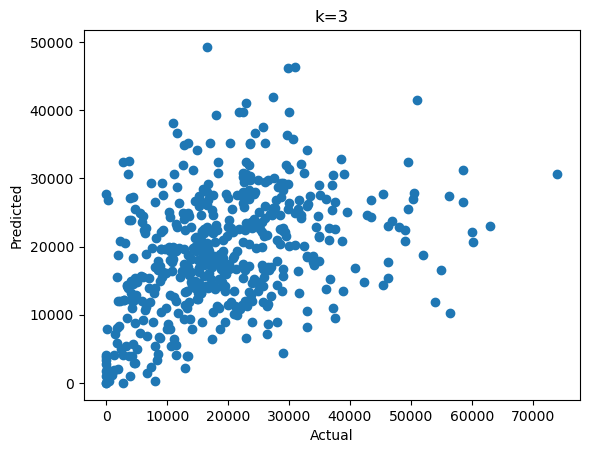

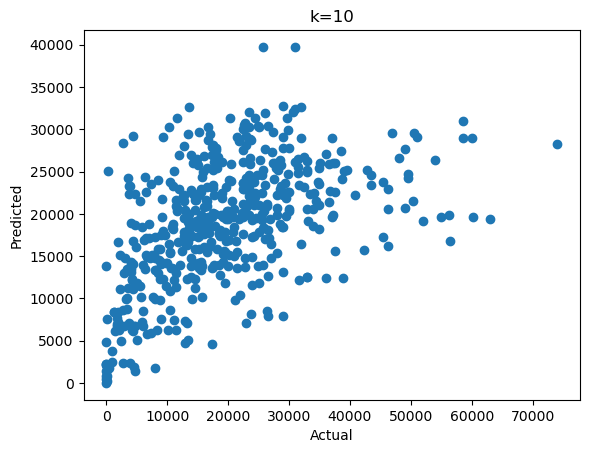

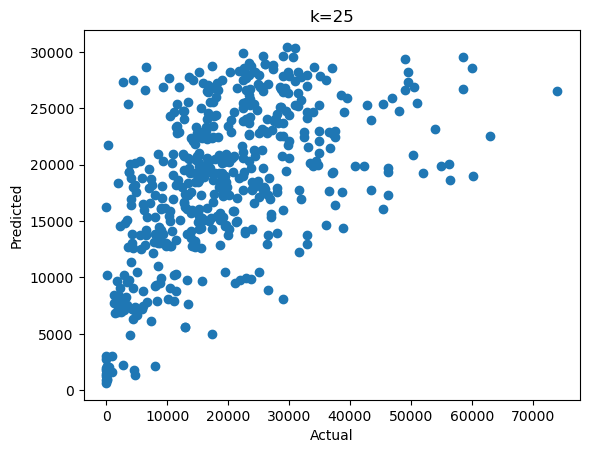

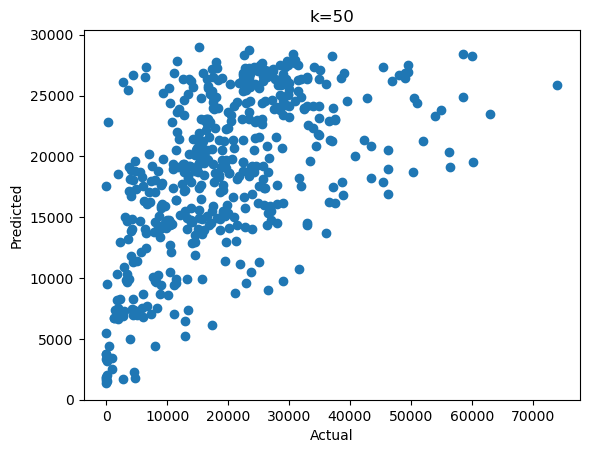

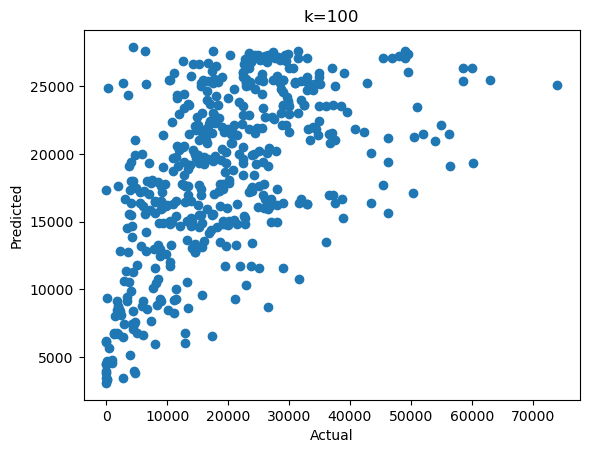

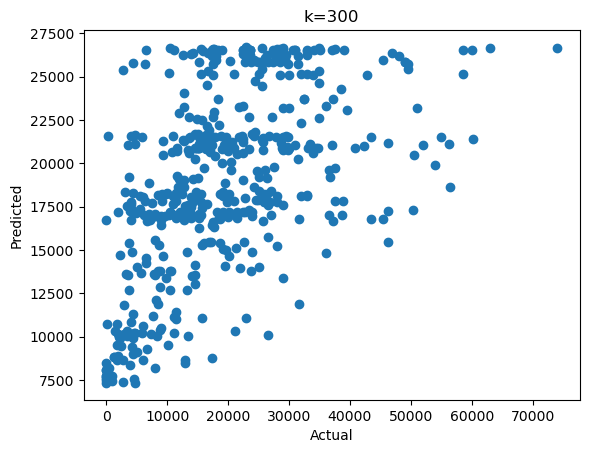

{3: 148104157.1862222, 10: 117399126.10604002, 25: 112600455.15990078, 50: 110202287.21426159, 100: 112250845.4893072, 300: 114497778.21548478}


In [77]:
k_values = [3, 10, 25, 50, 100, 300]
mse = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mse[k] = mean_squared_error(y_test, pred)
    
    plt.scatter(y_test, pred)
    plt.title(f"k={k}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

print(mse)

5. Determine the optimal $k$ for these data.


In [78]:
best_k = min(mse, key=mse.get)
print("Optimal k:", best_k)

Optimal k: 50


6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

When k was smaller it tended to overfit, but as it got larger, it tended to underfit.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.


In [79]:
airbnb = pd.read_csv('datasets/airbnb_hw.csv')
airbnb.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [80]:
airbnb.loc[:, ['Review Scores Rating', 'Price', 'Beds']]

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0
...,...,...,...
30473,NaN,300,5.0
30474,NaN,125,2.0
30475,NaN,80,1.0
30476,NaN,35,1.0


2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.


In [81]:
nulls = airbnb.loc[airbnb['Review Scores Rating'].isnull(), :]

3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.


In [82]:
cars = cars.dropna(axis = 0, how = 'any')
cars.head()

,Unnamed: 0,price,year,mileage
0,0,6300,2008,274117
1,1,2899,2011,190552
2,2,5350,2018,39590
3,3,25000,2014,64146
4,4,27700,2018,6654


4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)


In [83]:
airbnb['Price'] = pd.to_numeric(airbnb['Price'].astype(str).str.replace(r'[^0-9.\-]', '', regex=True), errors='coerce')
airbnb['Beds']  = pd.to_numeric(airbnb['Beds'], errors='coerce')

complete = airbnb.loc[airbnb[['Review Scores Rating', 'Price', 'Beds']].notna().all(axis=1), :]
X = complete[['Price', 'Beds']]
y = complete['Review Scores Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [84]:
import numpy as np

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 31)
sse_list = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    sse = np.sum((y_test - y_pred)**2)
    sse_list.append(sse)

best_k = k_values[np.argmin(sse_list)]
best_k

30

5. Predict the missing ratings. 


In [85]:
best_model = KNeighborsRegressor(n_neighbors=best_k)
scaler = StandardScaler()
X_complete_scaled = scaler.fit_transform(X)
best_model.fit(X_complete_scaled, y)
mask = (
    airbnb['Review Scores Rating'].isnull() &
    airbnb[['Price', 'Beds']].notna().all(axis=1)
)

X_missing = airbnb.loc[mask, ['Price', 'Beds']]
X_missing_scaled = scaler.transform(X_missing)


predicted_ratings = best_model.predict(X_missing_scaled)

airbnb.loc[mask, 'Review Scores Rating'] = predicted_ratings

In [87]:
predicted_ratings

array([94.53333333, 90.56666667, 83.43333333, ..., 90.5       ,
       85.86666667, 90.5       ])

6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

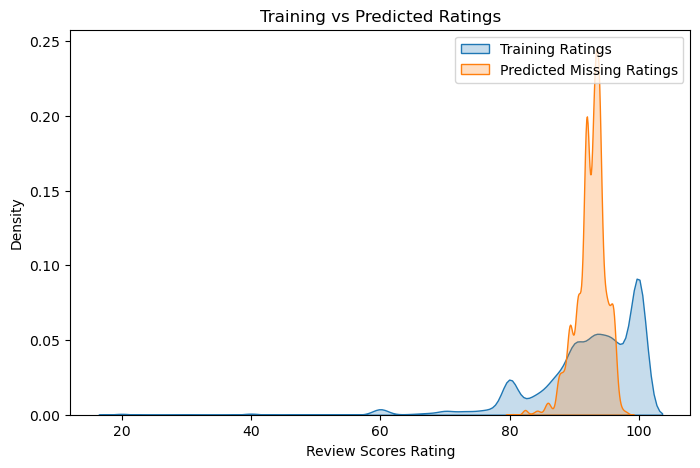

In [89]:
import seaborn as sns

training_ratings = y

predicted_vals = airbnb.loc[mask, 'Review Scores Rating']

plt.figure(figsize=(8,5))
sns.kdeplot(training_ratings, label='Training Ratings', fill=True)
sns.kdeplot(predicted_vals, label='Predicted Missing Ratings', fill=True)
plt.legend()
plt.xlabel("Review Scores Rating")
plt.title("Training vs Predicted Ratings")
plt.show()

The different KDE's do not looks the same. It is clearly shown that the training ratings have higher spread, while the predicted missing ratings is more concentrated. This makes sense because the way prediction works is by finding the average ratings of nearby observations. Since we are using the data from the training rating to find the value, it will attribute and predict most of the missing data as the nearby observations average.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)